# 2. Preprocesado del Dataset

Este notebook convierte los TFRecords de Shallue & Vanderburg (2018) a formato CSV.

## Datos de entrada

Los TFRecords contienen curvas de luz de Kepler **ya preprocesadas**:
- **Flattening**: Variabilidad estelar eliminada con splines cúbicos
- **Phase Folding**: Tránsitos superpuestos y centrados en t=0
- **Binning**: Reducidos a vectores de longitud fija

## Contenido de cada ejemplo

| Campo | Descripción | Dimensión |
|-------|-------------|-----------|
| `global_view` | Curva de luz completa (todo el período) | 2001 |
| `local_view` | Zoom en el tránsito | 201 |
| `kepid` | ID de la estrella Kepler | 1 |
| `av_training_set` | Etiqueta (PC, AFP, NTP) | 1 |

## 2.1 Conversión de TFRecords a CSV

In [1]:
from tfrecord import tfrecord_loader
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

# Configuración de directorios
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
TFRECORD_DIR = DATA_DIR / "tfrecord"
PROCESSED_DIR = DATA_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Librerías cargadas")
print(f"✓ TFRecords en: {TFRECORD_DIR}")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/jorvarea/Desktop/Universidad/Tercer_curso/primer_cuatrimestre/Deep_Learning/practicas/venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/jorvarea/Desktop/Universidad/Tercer_curso/primer_cuatrimestre/Deep_Learning/practicas/venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start(

✓ Librerías cargadas
✓ TFRecords en: data/tfrecord


### Funciones de conversión

In [ ]:
# Descripción de los campos del TFRecord
FEATURE_DESCRIPTION = {
    'global_view': 'float',
    'local_view': 'float', 
    'kepid': 'int',
    'tce_plnt_num': 'int',
    'av_training_set': 'byte',
}


def tfrecords_to_dataframe(file_paths: list[Path]) -> pd.DataFrame:
    """
    Convierte múltiples archivos TFRecord a un DataFrame de pandas.
    """
    records = []
    
    for file_path in tqdm(file_paths, desc="Leyendo TFRecords"):
        loader = tfrecord_loader(str(file_path), None, FEATURE_DESCRIPTION)
        
        for features in loader:
            record = {
                'kepid': features['kepid'][0],
                'tce_plnt_num': features['tce_plnt_num'][0],
                'av_training_set': features['av_training_set'].decode('utf-8'),
            }
            
            # Añadir global_view como columnas separadas
            global_view = features['global_view']
            for i, val in enumerate(global_view):
                record[f'global_{i}'] = val
            
            # Añadir local_view como columnas separadas
            local_view = features['local_view']
            for i, val in enumerate(local_view):
                record[f'local_{i}'] = val
            
            records.append(record)
    
    return pd.DataFrame(records)


print("✓ Funciones definidas")

✓ Funciones definidas


In [3]:
# Listar archivos TFRecord
train_files = sorted(TFRECORD_DIR.glob("train-*"))
val_files = sorted(TFRECORD_DIR.glob("val-*"))
test_files = sorted(TFRECORD_DIR.glob("test-*"))

print(f"Archivos encontrados:")
print(f"  - Training: {len(train_files)} shards")
print(f"  - Validation: {len(val_files)} shards")
print(f"  - Test: {len(test_files)} shards")

Archivos encontrados:
  - Training: 8 shards
  - Validation: 1 shards
  - Test: 1 shards


### Conversión a DataFrame

In [4]:
# Convertir Training (8 shards → 1 DataFrame)
print("Convirtiendo Training...")
df_train = tfrecords_to_dataframe(train_files)
print(f"✓ Training: {len(df_train):,} registros")

# Convertir Validation
print("\nConvirtiendo Validation...")
df_val = tfrecords_to_dataframe(val_files)
print(f"✓ Validation: {len(df_val):,} registros")

# Convertir Test
print("\nConvirtiendo Test...")
df_test = tfrecords_to_dataframe(test_files)
print(f"✓ Test: {len(df_test):,} registros")

Convirtiendo Training...


Leyendo TFRecords:   0%|          | 0/8 [00:00<?, ?it/s]

Leyendo TFRecords: 100%|██████████| 8/8 [00:21<00:00,  2.66s/it]


✓ Training: 12,589 registros

Convirtiendo Validation...


Leyendo TFRecords: 100%|██████████| 1/1 [00:01<00:00,  1.76s/it]


✓ Validation: 1,574 registros

Convirtiendo Test...


Leyendo TFRecords: 100%|██████████| 1/1 [00:01<00:00,  1.63s/it]


✓ Test: 1,574 registros


In [5]:
# Crear etiqueta binaria
# PC (Planet Candidate) -> 1
# AFP, NTP -> 0

for df in [df_train, df_val, df_test]:
    df['label'] = (df['av_training_set'] == 'PC').astype(int)

# Estadísticas
print("Distribución de clases:")
print("\nTraining:")
print(df_train['av_training_set'].value_counts())
print(f"  → Positivos (PC): {df_train['label'].sum():,}")
print(f"  → Negativos: {(~df_train['label'].astype(bool)).sum():,}")

print("\nValidation:")
print(df_val['av_training_set'].value_counts())

print("\nTest:")
print(df_test['av_training_set'].value_counts())

Distribución de clases:

Training:
av_training_set
AFP    7643
PC     2885
NTP    2061
Name: count, dtype: int64
  → Positivos (PC): 2,885
  → Negativos: 9,704

Validation:
av_training_set
AFP    983
PC     355
NTP    236
Name: count, dtype: int64

Test:
av_training_set
AFP    970
PC     360
NTP    244
Name: count, dtype: int64


In [6]:
# Guardar como CSV
df_train.to_csv(PROCESSED_DIR / "train.csv", index=False)
df_val.to_csv(PROCESSED_DIR / "val.csv", index=False)
df_test.to_csv(PROCESSED_DIR / "test.csv", index=False)

print(f"✓ Archivos guardados en {PROCESSED_DIR}:")
print(f"  - train.csv ({len(df_train):,} filas)")
print(f"  - val.csv ({len(df_val):,} filas)")
print(f"  - test.csv ({len(df_test):,} filas)")

# Tamaño de los archivos
for f in PROCESSED_DIR.glob("*.csv"):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  - {f.name}: {size_mb:.1f} MB")

✓ Archivos guardados en data/processed:
  - train.csv (12,589 filas)
  - val.csv (1,574 filas)
  - test.csv (1,574 filas)
  - val.csv: 38.9 MB
  - test.csv: 38.8 MB
  - train.csv: 310.6 MB


## 2.2 Exploración de los datos

In [7]:
import matplotlib.pyplot as plt

# Ver estructura del DataFrame
print(f"Columnas totales: {len(df_train.columns)}")
print(f"  - Metadatos: kepid, tce_plnt_num, av_training_set, label")
print(f"  - global_view: global_0 ... global_2000 (2001 columnas)")
print(f"  - local_view: local_0 ... local_200 (201 columnas)")

df_train.head()

Columnas totales: 2206
  - Metadatos: kepid, tce_plnt_num, av_training_set, label
  - global_view: global_0 ... global_2000 (2001 columnas)
  - local_view: local_0 ... local_200 (201 columnas)


,kepid,tce_plnt_num,av_training_set,global_0,global_1,global_2,global_3,global_4,global_5,global_6,...,local_192,local_193,local_194,local_195,local_196,local_197,local_198,local_199,local_200,label
0,11709124,2,PC,0.023022,-0.076446,0.014463,0.034534,-0.001771,-0.023170,-0.023687,...,0.079112,-0.012477,0.015630,0.003839,-0.092891,-0.048194,-0.030986,-0.030986,0.003702,1
1,5471217,1,AFP,-0.018312,0.143718,0.113584,0.146963,0.105239,-0.216504,-0.494437,...,-0.020982,-0.060428,-0.098196,0.088963,0.000000,0.127570,0.058749,0.005875,-0.043642,0
2,5732026,1,NTP,-0.007593,-0.080023,0.330607,-0.015187,-0.355140,-0.366822,0.327103,...,0.112176,0.017258,-0.061361,-0.124640,-0.238734,-0.258869,-0.258869,-0.238734,-0.299616,0
3,10122538,4,PC,-0.123447,0.418671,-0.096480,-0.315906,0.243767,0.207535,0.179329,...,-0.007532,-0.056338,-0.062823,-0.083714,-0.113333,-0.016079,-0.016079,-0.033653,0.065872,1
4,4947556,2,PC,0.033677,-0.116284,0.168780,0.004754,-0.051902,0.007528,-0.161648,...,0.335568,0.177203,0.151980,0.145594,0.144636,0.151980,0.234036,0.468391,0.181034,1


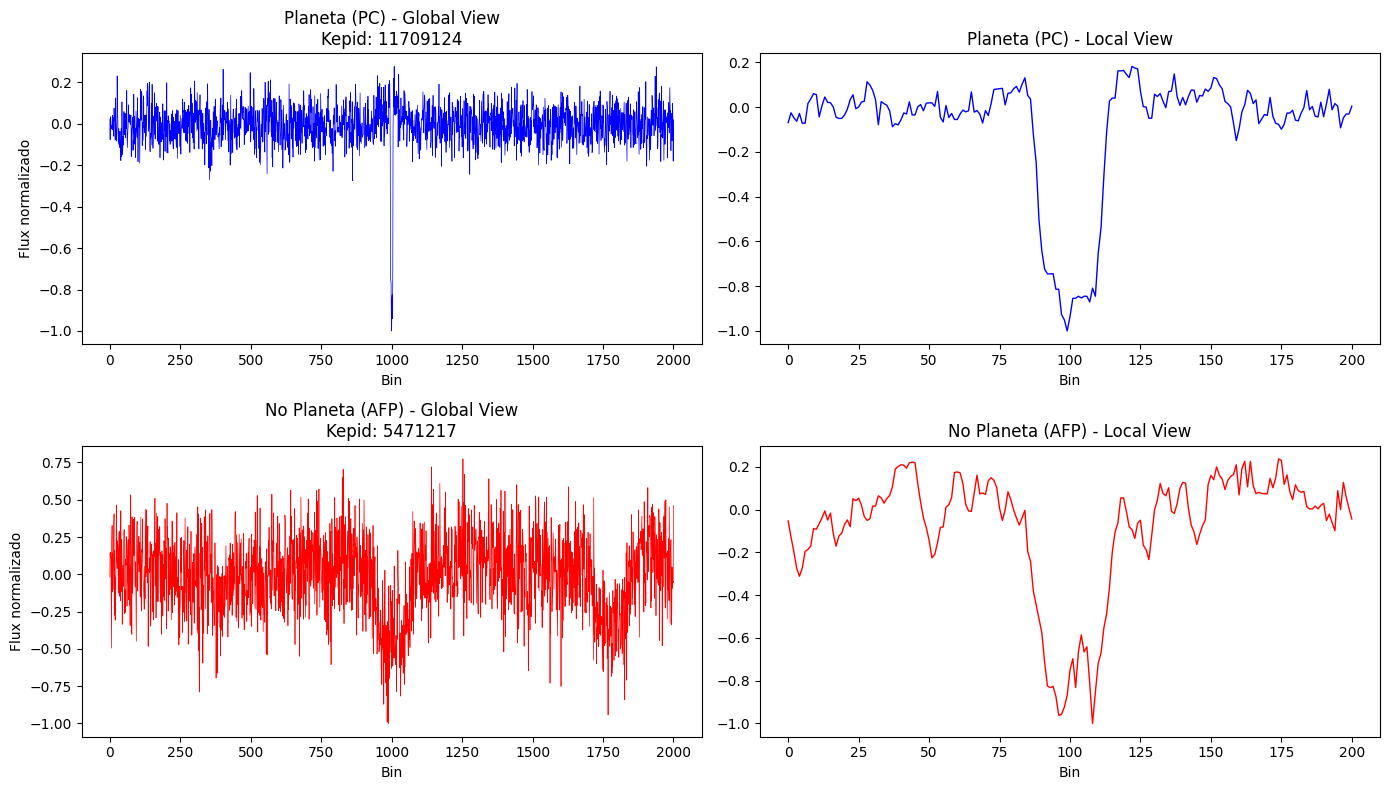

In [8]:
# Visualizar ejemplos
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Columnas de features
global_cols = [c for c in df_train.columns if c.startswith('global_')]
local_cols = [c for c in df_train.columns if c.startswith('local_')]

# Ejemplo positivo (planeta)
positive_example = df_train[df_train['label'] == 1].iloc[0]

axes[0, 0].plot(positive_example[global_cols].values, 'b-', linewidth=0.5)
axes[0, 0].set_title(f"Planeta (PC) - Global View\nKepid: {positive_example['kepid']}")
axes[0, 0].set_xlabel("Bin")
axes[0, 0].set_ylabel("Flux normalizado")

axes[0, 1].plot(positive_example[local_cols].values, 'b-', linewidth=1)
axes[0, 1].set_title(f"Planeta (PC) - Local View")
axes[0, 1].set_xlabel("Bin")

# Ejemplo negativo (falso positivo)
negative_example = df_train[df_train['label'] == 0].iloc[0]

axes[1, 0].plot(negative_example[global_cols].values, 'r-', linewidth=0.5)
axes[1, 0].set_title(f"No Planeta ({negative_example['av_training_set']}) - Global View\nKepid: {negative_example['kepid']}")
axes[1, 0].set_xlabel("Bin")
axes[1, 0].set_ylabel("Flux normalizado")

axes[1, 1].plot(negative_example[local_cols].values, 'r-', linewidth=1)
axes[1, 1].set_title(f"No Planeta ({negative_example['av_training_set']}) - Local View")
axes[1, 1].set_xlabel("Bin")

plt.tight_layout()
plt.show()

In [9]:
# Resumen final
total = len(df_train) + len(df_val) + len(df_test)
total_positive = df_train['label'].sum() + df_val['label'].sum() + df_test['label'].sum()
total_negative = total - total_positive

print("="*50)
print("RESUMEN DEL DATASET")
print("="*50)
print(f"Total de ejemplos: {total:,}")
print(f"  - Training: {len(df_train):,} ({100*len(df_train)/total:.1f}%)")
print(f"  - Validation: {len(df_val):,} ({100*len(df_val)/total:.1f}%)")
print(f"  - Test: {len(df_test):,} ({100*len(df_test)/total:.1f}%)")
print()
print(f"Distribución de clases (total):")
print(f"  - Positivos (PC): {total_positive:,} ({100*total_positive/total:.1f}%)")
print(f"  - Negativos (AFP+NTP): {total_negative:,} ({100*total_negative/total:.1f}%)")
print(f"  - Ratio de desbalance: 1:{total_negative/total_positive:.2f}")
print()
print(f"Dimensiones de entrada:")
print(f"  - Global view: 2001 features")
print(f"  - Local view: 201 features")

RESUMEN DEL DATASET
Total de ejemplos: 15,737
  - Training: 12,589 (80.0%)
  - Validation: 1,574 (10.0%)
  - Test: 1,574 (10.0%)

Distribución de clases (total):
  - Positivos (PC): 3,600 (22.9%)
  - Negativos (AFP+NTP): 12,137 (77.1%)
  - Ratio de desbalance: 1:3.37

Dimensiones de entrada:
  - Global view: 2001 features
  - Local view: 201 features
